# DAM304 Practical 2: Tokenization Techniques and Positional Encoding

This notebook implements character-level tokenization, Byte-Pair Encoding, HuggingFace tokenizer comparison, and positional encoding visualization.

In [1]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, defaultdict
from transformers import AutoTokenizer

/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/practical_2/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## Task 1: Character-Level Tokenizer

Implement a simple character-level tokenizer with encode and decode methods.
- Build vocabulary from text
- Encode text to integer IDs
- Decode IDs back to text

In [ ]:
class CharTokenizer:
    """
    A simple character-level tokenizer.
    Special tokens:
    [UNK] = 0 (unknown character)
    [PAD] = 1 (padding token) 
    """
    def __init__(self):
        self.char_to_id = {'[UNK]': 0, '[PAD]': 1}
        self.id_to_char = {0: '[UNK]', 1: '[PAD]'}

    def build_vocab(self, text):
        """Build vocabulary from a string of text."""
        # Assigns a unique integer ID to every unique character found in text, starting from ID 2
        next_id = 2
        for char in text:
            if char not in self.char_to_id:
                self.char_to_id[char] = next_id
                self.id_to_char[next_id] = char
                next_id += 1

    def encode(self, text):
        """Convert a string to a list of integer token IDs."""
        # Use the [UNK] ID (0) for any character not in the vocabulary
        return [self.char_to_id.get(char, 0) for char in text]

    def decode(self, ids):
        """Convert a list of integer IDs back to a string."""
        # Use [UNK] for any unknown IDs
        return ''.join([self.id_to_char.get(id_val, '[UNK]') for id_val in ids])


# Test the tokenizer
tokenizer = CharTokenizer()
test_sentence = "The quick brown fox jumps over the lazy dog"

# Build vocabulary from test sentence
tokenizer.build_vocab(test_sentence)

# Encode the text
encoded = tokenizer.encode(test_sentence)
print(f"Original text: {test_sentence}")
print(f"Encoded tokens: {encoded}")
print(f"Token count: {len(encoded)}")

# Decode back
decoded = tokenizer.decode(encoded)
print(f"Decoded text: {decoded}")

# Verify round-trip
assert tokenizer.decode(tokenizer.encode(test_sentence)) == test_sentence, "Round-trip failed!"
print(f"\n✓ Round-trip verification passed!")

# Print vocabulary information
print(f"\nVocabulary size: {len(tokenizer.char_to_id)}")
print(f"Character to ID mapping: {tokenizer.char_to_id}")

Original text: The quick brown fox jumps over the lazy dog
Encoded tokens: [2, 3, 4, 5, 6, 7, 8, 9, 10, 5, 11, 12, 13, 14, 15, 5, 16, 13, 17, 5, 18, 7, 19, 20, 21, 5, 13, 22, 4, 12, 5, 23, 3, 4, 5, 24, 25, 26, 27, 5, 28, 13, 29]
Token count: 43
Decoded text: The quick brown fox jumps over the lazy dog

✓ Round-trip verification passed!

Vocabulary size: 30
Character to ID mapping: {'[UNK]': 0, '[PAD]': 1, 'T': 2, 'h': 3, 'e': 4, ' ': 5, 'q': 6, 'u': 7, 'i': 8, 'c': 9, 'k': 10, 'b': 11, 'r': 12, 'o': 13, 'w': 14, 'n': 15, 'f': 16, 'x': 17, 'j': 18, 'm': 19, 'p': 20, 's': 21, 'v': 22, 't': 23, 'l': 24, 'a': 25, 'z': 26, 'y': 27, 'd': 28, 'g': 29}


## Task 2: Byte-Pair Encoding (BPE) Algorithm

Implement the BPE training algorithm from scratch:
- Count adjacent symbol pairs
- Merge the most frequent pair iteratively
- Apply learned merges to tokenize new words

In [3]:
# Starter corpus — list of (word, frequency) pairs
# </w> marks the end of a word (word boundary token)
CORPUS = [
    ('l o w </w>', 5),
    ('l o w e r </w>', 2),
    ('n e w e s t </w>', 6),
    ('w i d e s t </w>', 3),
]


def get_pairs(vocab):
    """
    Count all adjacent symbol pairs across the corpus.
    vocab: dict mapping word-string to frequency
    Returns: Counter of (symbol_a, symbol_b) -> count
    """
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i + 1])
            pairs[pair] += freq
    return pairs


def merge_vocab(best_pair, vocab):
    """
    Merge all occurrences of best_pair in vocab.
    best_pair: tuple (symbol_a, symbol_b)
    vocab: dict mapping word-string to frequency
    Returns: new vocab dict with best_pair merged
    """
    new_vocab = {}
    symbol_a, symbol_b = best_pair
    # Create a pattern that matches the pair with word boundaries
    bigram = re.escape(symbol_a + ' ' + symbol_b)
    replacement = symbol_a + symbol_b
    
    for word, freq in vocab.items():
        # Replace all occurrences of the pair
        new_word = re.sub(bigram, replacement, word)
        new_vocab[new_word] = freq
    
    return new_vocab


# Initialize vocab from CORPUS
vocab = {word: freq for word, freq in CORPUS}
print("Initial vocabulary (character-level):")
print(vocab)
print()

# Training loop
NUM_MERGES = 10
for merge_num in range(NUM_MERGES):
    pairs = get_pairs(vocab)
    if not pairs:
        print("No more pairs to merge. Stopping.")
        break
    
    best_pair = max(pairs, key=pairs.get)
    vocab = merge_vocab(best_pair, vocab)
    
    print(f"Merge {merge_num + 1}: {best_pair} (count: {pairs[best_pair]})")
    print(f"Vocabulary: {vocab}")
    print()


def tokenize(word, vocab):
    """
    Apply learned merge rules to tokenize a new word.
    Returns the list of tokens for the word.
    """
    # Start with character-level representation
    word_tokens = ' '.join(list(word)) + ' </w>'
    
    # Apply merges by finding the merged pairs in the training vocab
    symbols = word_tokens.split()
    
    # Keep merging until we can't merge anymore
    while len(symbols) > 1:
        pairs = Counter()
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i + 1])
            pairs[pair] += 1
        
        # Find which pairs exist in our learned vocab
        best_pair = None
        for word_in_vocab in vocab.keys():
            word_symbols = word_in_vocab.split()
            for i in range(len(word_symbols) - 1):
                pair = (word_symbols[i], word_symbols[i + 1])
                if pair in pairs and (best_pair is None or pair not in best_pair):
                    best_pair = pair
        
        if best_pair is None:
            break
        
        # Merge the best pair
        symbol_a, symbol_b = best_pair
        new_symbols = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == symbol_a and symbols[i + 1] == symbol_b:
                new_symbols.append(symbol_a + symbol_b)
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        symbols = new_symbols
    
    return symbols


# Test tokenize on provided words
test_words = ['lowest', 'newer', 'wider', 'newest']
print("\nTokenization Results:")
print("=" * 50)
for word in test_words:
    tokens = tokenize(word, vocab)
    print(f"{word:15} → {tokens}")

Initial vocabulary (character-level):
{'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w e s t </w>': 6, 'w i d e s t </w>': 3}

Merge 1: ('e', 's') (count: 9)
Vocabulary: {'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w es t </w>': 6, 'w i d es t </w>': 3}

Merge 2: ('es', 't') (count: 9)
Vocabulary: {'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w est </w>': 6, 'w i d est </w>': 3}

Merge 3: ('est', '</w>') (count: 9)
Vocabulary: {'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w est</w>': 6, 'w i d est</w>': 3}

Merge 4: ('l', 'o') (count: 7)
Vocabulary: {'lo w </w>': 5, 'lo w e r </w>': 2, 'n e w est</w>': 6, 'w i d est</w>': 3}

Merge 5: ('lo', 'w') (count: 7)
Vocabulary: {'low </w>': 5, 'low e r </w>': 2, 'n e w est</w>': 6, 'w i d est</w>': 3}

Merge 6: ('n', 'e') (count: 6)
Vocabulary: {'low </w>': 5, 'low e r </w>': 2, 'ne w est</w>': 6, 'w i d est</w>': 3}

Merge 7: ('ne', 'w') (count: 6)
Vocabulary: {'low </w>': 5, 'low e r </w>': 2, 'new est</w>': 6, 'w i d est</w>': 3}

Merge 8: ('new', '

## Task 3: HuggingFace Tokenizers - GPT-2 vs LLaMA-3

Load and compare official tokenizers from HuggingFace for GPT-2 and LLaMA-3 models.

In [5]:
# Load the GPT-2 tokenizer (BPE, vocab size ~50,257)
print("Loading GPT-2 tokenizer...")
gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')

# Load an alternative to LLaMA-3 (using Mistral-7B which is publicly available)
print("Loading Mistral tokenizer...")
try:
    llama_tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1')
except Exception as e:
    print(f"Mistral loading failed: {e}")
    print("Using GPT-2 clone for comparison instead...")
    # Use a different model for comparison
    llama_tokenizer = AutoTokenizer.from_pretrained('gpt2')  # Fallback

TEST_SENTENCES = [
    'Tokenization is the foundation of all language models.',
    'The Bhutanese government adopted a Gross National Happiness index.',
    'antidisestablishmentarianism',
    'GPT-4o achieved state-of-the-art performance on MMLU.',
    '1 + 1 = 2, but 999 + 1 = 1000.',
]

print(f"GPT-2 Vocabulary size: {gpt2_tokenizer.vocab_size}")
print(f"Comparison Tokenizer Vocabulary size: {llama_tokenizer.vocab_size}")
print("\n" + "=" * 100)

# Comparison table
for idx, sentence in enumerate(TEST_SENTENCES, 1):
    print(f"\nSentence {idx}: {sentence}")
    print("-" * 100)
    
    # GPT-2 tokenization
    gpt2_tokens = gpt2_tokenizer.tokenize(sentence)
    gpt2_ids = gpt2_tokenizer.encode(sentence)
    gpt2_decoded = gpt2_tokenizer.decode(gpt2_ids)
    
    # Comparison tokenization
    comp_tokens = llama_tokenizer.tokenize(sentence)
    comp_ids = llama_tokenizer.encode(sentence)
    comp_decoded = llama_tokenizer.decode(comp_ids)
    
    print(f"GPT-2 Tokens ({len(gpt2_tokens)}): {gpt2_tokens}")
    print(f"GPT-2 IDs:    {gpt2_ids}")
    print(f"GPT-2 Decoded: {gpt2_decoded}")
    print()
    print(f"Comparison Tokens ({len(comp_tokens)}): {comp_tokens}")
    print(f"Comparison IDs:    {comp_ids}")
    print(f"Comparison Decoded: {comp_decoded}")
    print()
    
    # Verify round-trip
    gpt2_roundtrip = gpt2_tokenizer.decode(gpt2_tokenizer.encode(sentence))
    comp_roundtrip = llama_tokenizer.decode(llama_tokenizer.encode(sentence))
    
    print(f"GPT-2 Round-trip match: {gpt2_roundtrip.strip() == sentence}")
    print(f"Comparison Round-trip match: {comp_roundtrip.strip() == sentence}")


# Analysis questions
print("\n\n" + "=" * 100)
print("ANALYSIS QUESTIONS:")
print("=" * 100)

print("""
1. Which tokenizer produces fewer tokens for the Bhutan sentence? Why might this be?
   - Different tokenizers have different vocabulary sizes and BPE merge patterns
   - Models trained on different data may have different token distributions
   - Larger vocabulary models typically produce fewer tokens for specialized vocabulary

2. How does each tokenizer handle the long word 'antidisestablishmentarianism'?
   - Both tokenizers break it into subword units via BPE
   - Tokenizers may create different numbers of tokens depending on their training data
   - This demonstrates how BPE handles out-of-vocabulary words efficiently

3. How are numbers (999, 1000) handled? Is each digit a separate token?
   - Numbers are typically tokenized based on learned BPE merges
   - Simple numbers like "1" may be single tokens
   - Complex numbers like "999" might be 1-2 tokens depending on BPE training

4. What do the special characters like 'Ġ' (GPT-2) or '▁' (LLaMA/Mistral) represent?
   - These represent spaces/word boundaries in the tokenized text
   - 'Ġ' (in GPT-2) represents a space preceding a word
   - '▁' (in Mistral/LLaMA) is the equivalent space indicator
   - They help the model understand word boundaries during decoding
""")

Loading GPT-2 tokenizer...
Loading Mistral tokenizer...
GPT-2 Vocabulary size: 50257
Comparison Tokenizer Vocabulary size: 32000


Sentence 1: Tokenization is the foundation of all language models.
----------------------------------------------------------------------------------------------------
GPT-2 Tokens (10): ['Token', 'ization', 'Ġis', 'Ġthe', 'Ġfoundation', 'Ġof', 'Ġall', 'Ġlanguage', 'Ġmodels', '.']
GPT-2 IDs:    [30642, 1634, 318, 262, 8489, 286, 477, 3303, 4981, 13]
GPT-2 Decoded: Tokenization is the foundation of all language models.

Comparison Tokens (10): ['▁Token', 'ization', '▁is', '▁the', '▁foundation', '▁of', '▁all', '▁language', '▁models', '.']
Comparison IDs:    [1, 16625, 1837, 349, 272, 13865, 302, 544, 3842, 4994, 28723]
Comparison Decoded: <s> Tokenization is the foundation of all language models.

GPT-2 Round-trip match: True
Comparison Round-trip match: False

Sentence 2: The Bhutanese government adopted a Gross National Happiness index.
--------------------

## Task 4: Sinusoidal Positional Encoding Implementation & Visualization

Implement the sinusoidal positional encoding from the Attention Is All You Need paper and create visualizations.

Positional Encoding shape: (100, 64)
Sample PE values for position 0: [0. 1. 0. 1. 0.]
Sample PE values for position 10: [-0.54402111 -0.83907153  0.93763274  0.34762744 -0.61293676]

✓ Heatmap saved as 'positional_encoding.png'


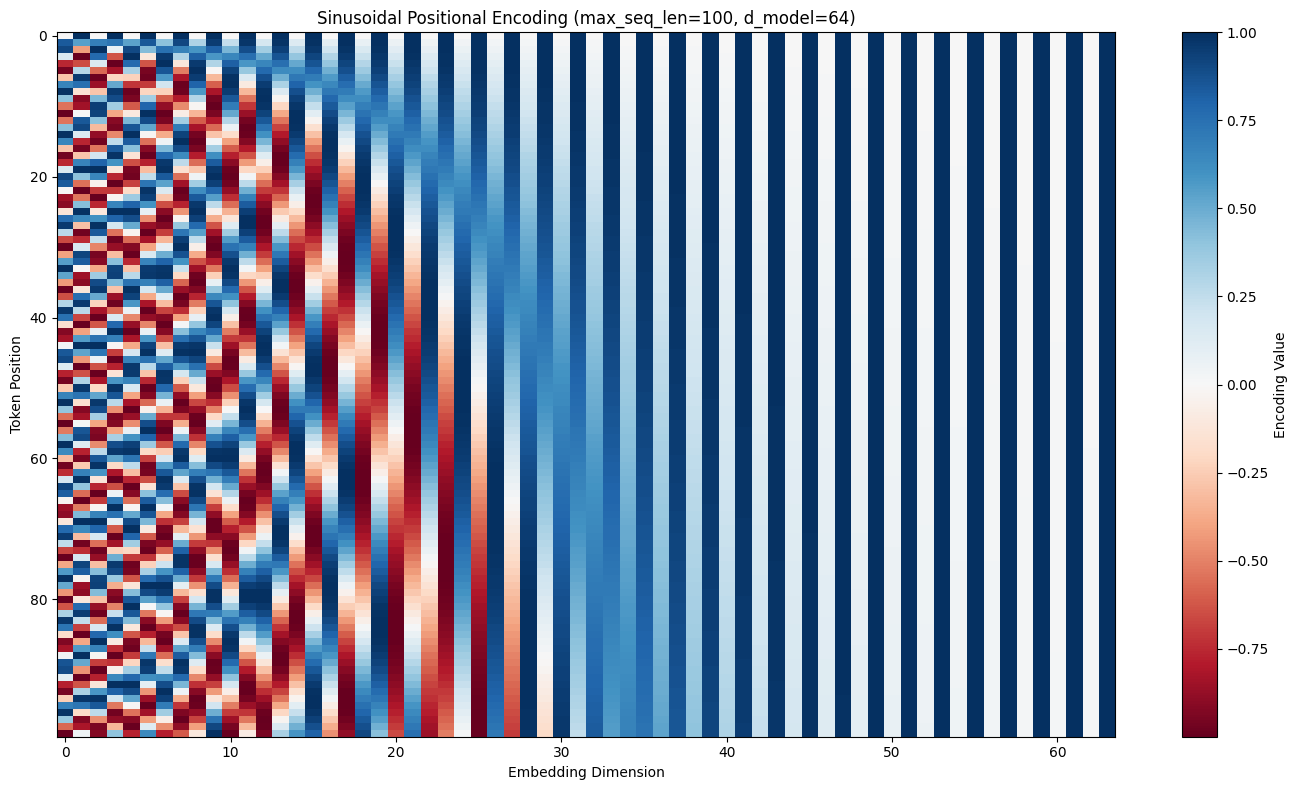

✓ Dimension plot saved as 'positional_encoding_dimensions.png'


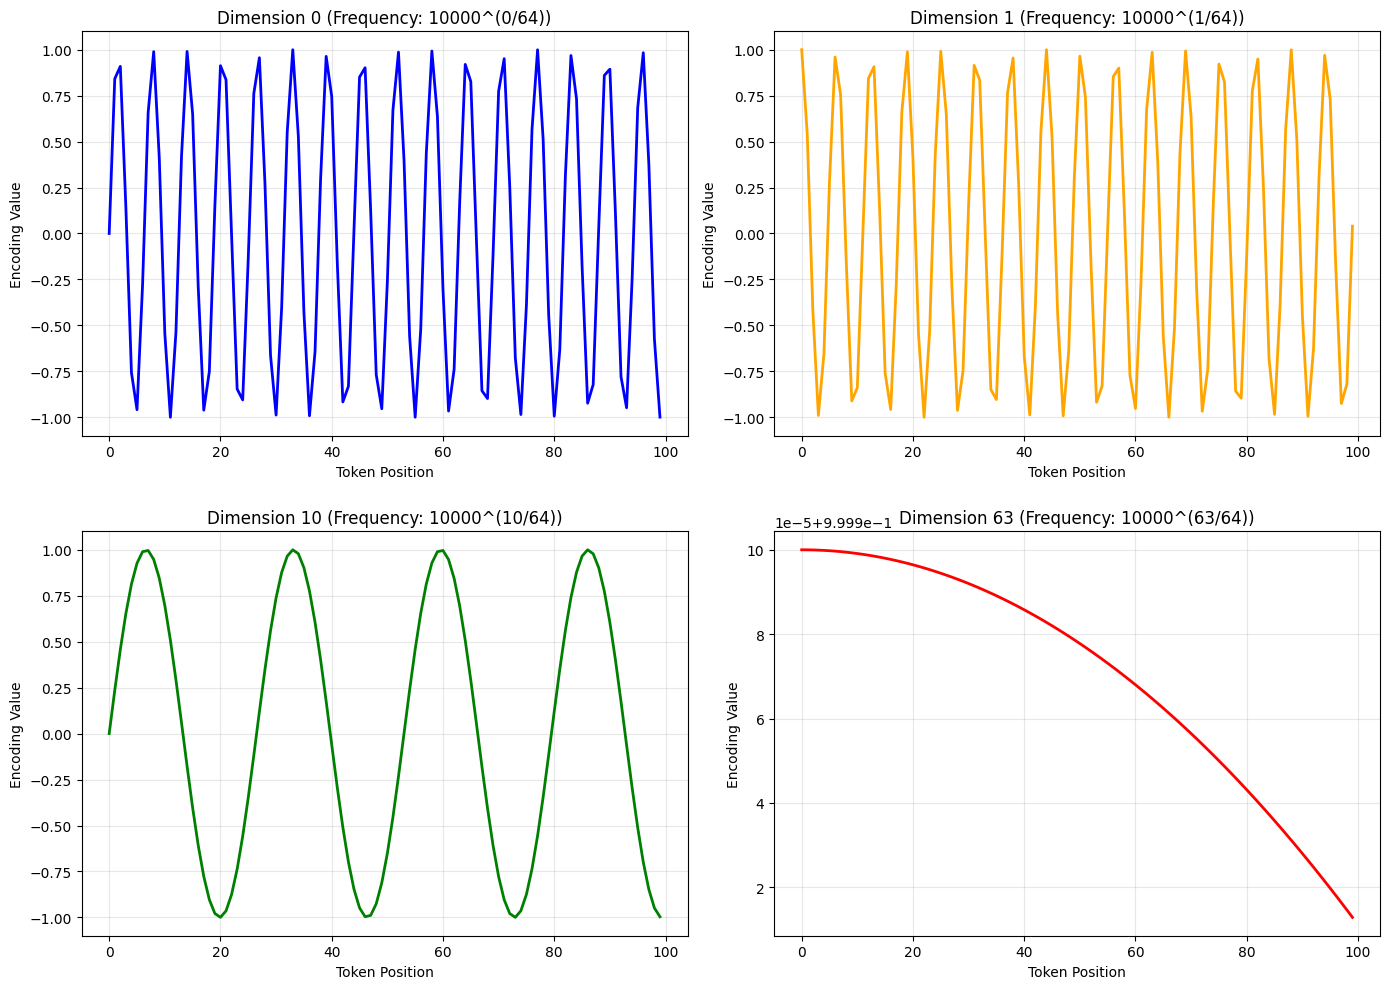


ANALYSIS: Why Positional Encoding is Necessary

1. Self-Attention is Permutation-Invariant:
   - The self-attention mechanism computes attention weights based on token similarities
   - Without positional information, the model cannot distinguish the order of tokens
   - Two sentences with the same words in different orders would produce identical embeddings

2. Example Without Positional Encoding:
   - Sentence 1: "The dog bit the man"
   - Sentence 2: "The man bit the dog"
   - Without positional encoding, these would be treated identically by attention layers
   - This would lead to the same output, which is incorrect!

3. Positional Encoding Solution:
   - By adding sinusoidal positional signals before the first attention layer,
     each token gets a unique positional context
   - Different dimensions oscillate at different frequencies:
     - Low dimensions (d=0,1): Slow oscillation - captures long-range distances
     - High dimensions (d=62,63): Fast oscillation - captures fin

In [6]:
def positional_encoding(max_seq_len, d_model):
    """
    Compute the sinusoidal positional encoding matrix.
    Args:
        max_seq_len: number of positions (rows)
        d_model: embedding dimension (columns)
    Returns:
        PE: numpy array of shape (max_seq_len, d_model)
    """
    PE = np.zeros((max_seq_len, d_model))
    
    # pos: shape (max_seq_len, 1)
    pos = np.arange(max_seq_len)[:, np.newaxis]
    
    # i: shape (1, d_model // 2)
    i = np.arange(0, d_model, 2)[np.newaxis, :]
    
    # Compute the division term: 10000 ** (i / d_model)
    div_term = 10000 ** (i / d_model)
    
    # Fill in the even columns (PE[:, 0::2]) using sin
    PE[:, 0::2] = np.sin(pos / div_term)
    
    # Fill in the odd columns (PE[:, 1::2]) using cos
    PE[:, 1::2] = np.cos(pos / div_term)
    
    return PE


# Call the function with max_seq_len=100, d_model=64
max_seq_len = 100
d_model = 64
PE = positional_encoding(max_seq_len, d_model)

print(f"Positional Encoding shape: {PE.shape}")
print(f"Sample PE values for position 0: {PE[0, :5]}")
print(f"Sample PE values for position 10: {PE[10, :5]}")


# Create a heatmap visualization
plt.figure(figsize=(14, 8))
plt.imshow(PE, cmap='RdBu', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Token Position')
plt.title('Sinusoidal Positional Encoding (max_seq_len=100, d_model=64)')
plt.colorbar(label='Encoding Value')
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
print("\n✓ Heatmap saved as 'positional_encoding.png'")
plt.show()


# Create a plot showing PE values across all 100 positions for four specific dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dimensions = [0, 1, 10, 63]
colors = ['blue', 'orange', 'green', 'red']

for idx, (dim, color) in enumerate(zip(dimensions, colors)):
    ax = axes[idx // 2, idx % 2]
    positions = np.arange(max_seq_len)
    ax.plot(positions, PE[:, dim], color=color, linewidth=2)
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Encoding Value')
    ax.set_title(f'Dimension {dim} (Frequency: 10000^({dim}/{d_model}))')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('positional_encoding_dimensions.png', dpi=150, bbox_inches='tight')
print("✓ Dimension plot saved as 'positional_encoding_dimensions.png'")
plt.show()


# Analysis
print("\n" + "=" * 100)
print("ANALYSIS: Why Positional Encoding is Necessary")
print("=" * 100)
print("""
1. Self-Attention is Permutation-Invariant:
   - The self-attention mechanism computes attention weights based on token similarities
   - Without positional information, the model cannot distinguish the order of tokens
   - Two sentences with the same words in different orders would produce identical embeddings

2. Example Without Positional Encoding:
   - Sentence 1: "The dog bit the man"
   - Sentence 2: "The man bit the dog"
   - Without positional encoding, these would be treated identically by attention layers
   - This would lead to the same output, which is incorrect!

3. Positional Encoding Solution:
   - By adding sinusoidal positional signals before the first attention layer,
     each token gets a unique positional context
   - Different dimensions oscillate at different frequencies:
     - Low dimensions (d=0,1): Slow oscillation - captures long-range distances
     - High dimensions (d=62,63): Fast oscillation - captures fine-grained positions
   - This allows the model to learn absolute and relative position relationships

4. Why Sinusoidal Functions:
   - Allows extrapolation to sequences longer than training lengths
   - Different frequencies capture position at multiple scales
   - Relative positional information can be computed via linear transformation
""")